<a href="https://colab.research.google.com/github/adilsher-dev/DEEP-LEARNING/blob/main/Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Features shape: (569, 30)
Labels shape: (569,)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target classes: ['malignant' 'benign']
Label 0: malignant
Label 1: benign
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.6126 - loss: 0.6456 - val_accuracy: 0.8352 - val_loss: 0.4630
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9231 - loss: 0.3704 - val_accuracy: 0.9121 - val_loss: 0.2951
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - ac

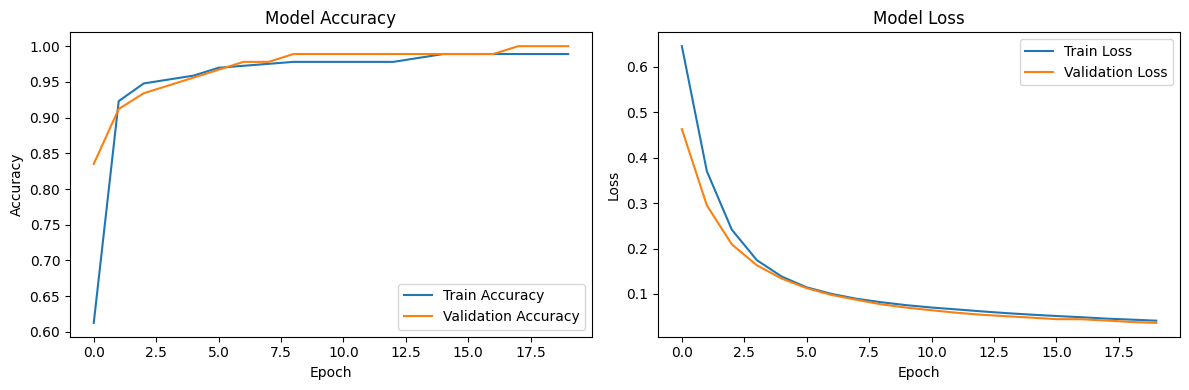


Predicted probability for class 1 (benign): 0.0000
Predicted class: malignant
Actual class: malignant


In [1]:


import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models

#  Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("Feature names:", data.feature_names)
print("Target classes:", data.target_names)
print("Label 0:", data.target_names[0])  # malignant
print("Label 1:", data.target_names[1])  # benign

#
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


test_loss, test_accuracy = model.evaluate(
    X_test, y_test, verbose=0
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


sample_input = X_test[0:1]
prediction = model.predict(sample_input, verbose=0)[0][0]

predicted_class = 1 if prediction >= 0.5 else 0

print("\nPredicted probability for class 1 (benign):",
      f"{prediction:.4f}")
print("Predicted class:", data.target_names[predicted_class])
print("Actual class:", data.target_names[y_test[0]])
